In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Scripts\python.exe
3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [2]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

In [3]:
# Set or create an experiment
mlflow.set_experiment("Exp 2 - BoW vs TfIdf")

c:\Users\Soham\Documents\youtube comment analyzer\yt_env\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:c:/Users/Soham/Documents/youtube comment '
 'analyzer/mlruns/993894957101575721'), creation_time=1778696579663, experiment_id='993894957101575721', last_update_time=1778696579663, lifecycle_stage='active', name='Exp 2 - BoW vs TfIdf', tags={}, trace_location=None, workspace='default'>

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import joblib

In [2]:
df = pd.read_csv('reddit_preprocessing.csv').dropna(subset=['clean_comment'])
df.shape

(36662, 2)

In [6]:
results = []


In [7]:

# Step 1: Function to run the experiment
def run_experiment(vectorizer_type, ngram_range, vectorizer_max_features, vectorizer_name):
    # Step 2: Vectorization
    if vectorizer_type == "BoW":
        vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)
    else:
        vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=vectorizer_max_features)

    X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)

    # Step 4: Define and train a Random Forest model
    with mlflow.start_run() as run:
        # Set tags for the experiment and run
        mlflow.set_tag("mlflow.runName", f"{vectorizer_name}_{ngram_range}_RandomForest")
        mlflow.set_tag("experiment_type", "feature_engineering")
        mlflow.set_tag("model_type", "RandomForestClassifier")

        # Add a description
        mlflow.set_tag("description", f"RandomForest with {vectorizer_name}, ngram_range={ngram_range}, max_features={vectorizer_max_features}")

        # Log vectorizer parameters
        mlflow.log_param("vectorizer_type", vectorizer_type)
        mlflow.log_param("ngram_range", ngram_range)
        mlflow.log_param("vectorizer_max_features", vectorizer_max_features)

        # Log Random Forest parameters
        n_estimators = 200
        max_depth = 15

        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)

        # Initialize and train the model
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Step 5: Make predictions and log metrics
        y_pred = model.predict(X_test)

        # Log accuracy
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric("accuracy", accuracy)

        # Log classification report
        classification_rep = classification_report(y_test, y_pred, output_dict=True)
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        # Log confusion matrix
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix: {vectorizer_name}, {ngram_range}")
        plt.savefig("confusion_matrix.png")
        mlflow.log_artifact("confusion_matrix.png")
        plt.close()

        # Log the model
        mlflow.sklearn.log_model(model, f"random_forest_model_{vectorizer_name}_{ngram_range}")

# Step 6: Run experiments for BoW and TF-IDF with different n-grams
ngram_ranges = [(1, 1), (1, 2), (1, 3)]  # unigrams, bigrams, trigrams
max_features = 5000  # Example max feature size

for ngram_range in ngram_ranges:
    # BoW Experiments
    run_experiment("BoW", ngram_range, max_features, vectorizer_name="BoW")

    # TF-IDF Experiments
    run_experiment("TF-IDF", ngram_range, max_features, vectorizer_name="TF-IDF")


2026/05/16 21:42:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 21:42:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/16 21:43:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 21:43:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

2026/05/16 21:54:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 21:54:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/16 21:55:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 21:55:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

  Vectorizer   Ngram  Accuracy  Weighted_F1  Vocab_Size
0        BoW  (1, 1)  0.648029     0.572108        5000
1     TF-IDF  (1, 1)  0.649120     0.573081        5000
2        BoW  (1, 2)  0.656893     0.587684        5000
3     TF-IDF  (1, 2)  0.656757     0.585125        5000
4        BoW  (1, 3)  0.651711     0.578319        5000
5     TF-IDF  (1, 3)  0.653212     0.578654        5000


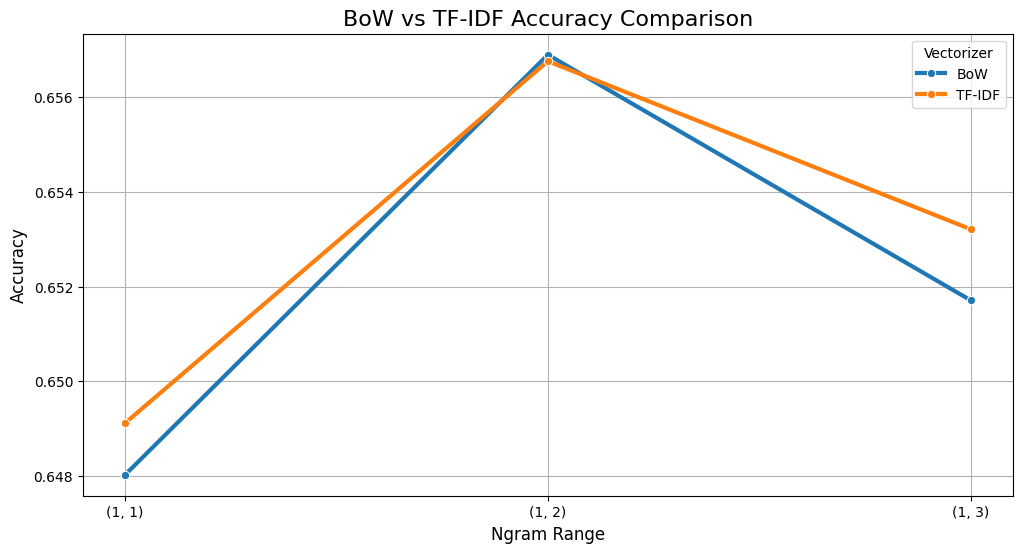

In [13]:
# ========================= FUNCTION =========================
def run_experiment(
    vectorizer_type,
    ngram_range,
    vectorizer_max_features,
    vectorizer_name
):

    # ---------- VECTORIZER ----------
    if vectorizer_type == "BoW":

        vectorizer = CountVectorizer(
            ngram_range=ngram_range,
            max_features=vectorizer_max_features
        )

    else:

        vectorizer = TfidfVectorizer(
            ngram_range=ngram_range,
            max_features=vectorizer_max_features
        )

    # ---------- TRAIN TEST SPLIT ----------
    X_train, X_test, y_train, y_test = train_test_split(
        df['clean_comment'],
        df['category'],
        test_size=0.2,
        random_state=42,
        stratify=df['category']
    )

    # ---------- VECTORIZATION ----------
    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test)

    # ---------- START RUN ----------
    with mlflow.start_run():

        # ---------- TAGS ----------
        mlflow.set_tag(
            "mlflow.runName",
            f"{vectorizer_name}_{ngram_range}_RF"
        )

        mlflow.set_tag(
            "experiment_type",
            "feature_engineering"
        )

        mlflow.set_tag(
            "model_type",
            "RandomForest"
        )

        # ---------- PARAMETERS ----------
        mlflow.log_param(
            "vectorizer_type",
            vectorizer_type
        )

        mlflow.log_param(
            "ngram_range",
            str(ngram_range)
        )

        mlflow.log_param(
            "max_features",
            vectorizer_max_features
        )

        # ---------- MODEL PARAMETERS ----------
        n_estimators = 200
        max_depth = 15

        mlflow.log_param(
            "n_estimators",
            n_estimators
        )

        mlflow.log_param(
            "max_depth",
            max_depth
        )

        # ---------- MODEL ----------
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        # ---------- TRAIN ----------
        model.fit(X_train, y_train)

        # ---------- PREDICT ----------
        y_pred = model.predict(X_test)

        # ---------- METRICS ----------
        accuracy = accuracy_score(y_test, y_pred)

        weighted_f1 = f1_score(
            y_test,
            y_pred,
            average='weighted'
        )

        vocab_size = len(vectorizer.vocabulary_)

        # ---------- LOG METRICS ----------
        mlflow.log_metric(
            "accuracy",
            accuracy
        )

        mlflow.log_metric(
            "weighted_f1",
            weighted_f1
        )

        mlflow.log_metric(
            "vocab_size",
            vocab_size
        )

        # ---------- CLASSIFICATION REPORT ----------
        classification_rep = classification_report(
            y_test,
            y_pred,
            output_dict=True
        )

        for label, metrics in classification_rep.items():

            if isinstance(metrics, dict):

                for metric, value in metrics.items():

                    mlflow.log_metric(
                        f"{label}_{metric}",
                        value
                    )

        # ---------- CONFUSION MATRIX ----------
        conf_matrix = confusion_matrix(
            y_test,
            y_pred
        )

        fig, ax = plt.subplots(figsize=(8, 6))

        sns.heatmap(
            conf_matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax
        )

        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        ax.set_title(
            f"Confusion Matrix\n"
            f"{vectorizer_name} {ngram_range}"
        )

        mlflow.log_figure(
            fig,
            f"conf_matrix_{vectorizer_name}_{ngram_range}.png"
        )

        plt.close(fig)

        # ---------- SAVE MODEL ----------
        mlflow.sklearn.log_model(
            model,
            f"rf_model_{vectorizer_name}_{ngram_range}"
        )

        # ---------- SAVE VECTORIZER ----------
        vectorizer_filename = (
            f"vectorizer_{vectorizer_name}_{ngram_range}.pkl"
        )

        joblib.dump(
            vectorizer,
            vectorizer_filename
        )

        mlflow.log_artifact(
            vectorizer_filename
        )

        # ---------- STORE RESULTS ----------
        results.append({

            "Vectorizer": vectorizer_name,

            "Ngram": str(ngram_range),

            "Accuracy": accuracy,

            "Weighted_F1": weighted_f1,

            "Vocab_Size": vocab_size
        })


# ========================= RUN EXPERIMENTS =========================
ngram_ranges = [
    (1, 1),
    (1, 2),
    (1, 3)
]

max_features = 5000

for ngram_range in ngram_ranges:

    # ---------- BOW ----------
    run_experiment(
        "BoW",
        ngram_range,
        max_features,
        "BoW"
    )

    # ---------- TFIDF ----------
    run_experiment(
        "TF-IDF",
        ngram_range,
        max_features,
        "TF-IDF"
    )


# ========================= RESULTS DATAFRAME =========================
results_df = pd.DataFrame(results)

print(results_df)


# ========================= COMPARISON PLOT =========================
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=results_df,
    x="Ngram",
    y="Accuracy",
    hue="Vectorizer",
    marker="o",
    linewidth=3,
    ax=ax
)

ax.set_title(
    "BoW vs TF-IDF Accuracy Comparison",
    fontsize=16
)

ax.set_xlabel(
    "Ngram Range",
    fontsize=12
)

ax.set_ylabel(
    "Accuracy",
    fontsize=12
)

ax.grid(True)

# ---------- SAVE COMPARISON GRAPH ----------
with mlflow.start_run(run_name="Overall_Comparison"):

    mlflow.log_figure(
        fig,
        "overall_comparison_plot.png"
    )

plt.show()

plt.close(fig)